In [31]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)

In [17]:
def get_xgb_model() -> XGBRegressor:
    xgb_model = XGBRegressor(
    n_estimators=100,       
    learning_rate=0.1,      
    max_depth=6,            
    subsample=0.8,          
    colsample_bytree=0.8,   
    random_state=42
    )
    return xgb_model

In [18]:
def get_rfr_model() -> RandomForestRegressor:
    rf_model = RandomForestRegressor(
    n_estimators=100,       
    max_depth=None,         
    min_samples_split=2,    
    min_samples_leaf=1,     
    max_features='auto',    
    random_state=42
    )
    return rf_model

In [23]:
def get_models() -> list:
    xgb_model = XGBRegressor(
    n_estimators=100,       
    learning_rate=0.1,      
    max_depth=6,            
    subsample=0.8,          
    colsample_bytree=0.8,   
    random_state=42
    )

    rf_model = RandomForestRegressor(
    n_estimators=100,       
    max_depth=None,         
    min_samples_split=2,    
    min_samples_leaf=1,     
    max_features='auto',    
    random_state=42
    )

    return [xgb_model, rf_model]


In [29]:
def calculate_metrics(y_test, y_pred) -> None:
    mse = mean_squared_error(y_pred, y_test)
    mae = mean_absolute_error(y_pred, y_test)
    r2 = r2_score(y_pred, y_test)

    res = pd.DataFrame({
        "MSE": mse,
        "MAE": mae,
        "R2": r2
    })

    print(res)

In [19]:
path = "datasets/mega_dataset_scaled.csv"  
df = pd.read_csv(path, parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,SLV,^GSPC,sent_enc,increase_ind
0,2023-01-03,0.030398,0.435045,0.0,0.0,0.234763,0.273613,0.007028,2,0
1,2023-01-04,0.048458,0.435045,0.0,0.0,0.303612,0.261619,0.019661,2,1
2,2023-01-05,0.024341,0.435045,0.0,0.0,0.193002,0.224138,0.000000,2,-1
3,2023-01-06,0.060123,0.435045,0.0,0.0,0.302483,0.263868,0.038113,2,1
4,2023-01-09,0.064498,0.435045,0.0,0.0,0.460497,0.250375,0.036803,0,1


In [20]:
df['Year'] = df['Date'].apply(lambda x: x.year)

scaler = MinMaxScaler()
df['Year_scaled'] = scaler.fit_transform(df[['Year']])
df.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,SLV,^GSPC,sent_enc,increase_ind,Year,Year_scaled
0,2023-01-03,0.030398,0.435045,0.0,0.0,0.234763,0.273613,0.007028,2,0,2023,0.0
1,2023-01-04,0.048458,0.435045,0.0,0.0,0.303612,0.261619,0.019661,2,1,2023,0.0
2,2023-01-05,0.024341,0.435045,0.0,0.0,0.193002,0.224138,0.000000,2,-1,2023,0.0
3,2023-01-06,0.060123,0.435045,0.0,0.0,0.302483,0.263868,0.038113,2,1,2023,0.0
4,2023-01-09,0.064498,0.435045,0.0,0.0,0.460497,0.250375,0.036803,0,1,2023,0.0


In [21]:
joblib.dump(scaler, 'scalers/year_scaler.pkl')

['scalers/year_scaler.pkl']

In [49]:
df['Gold_Price_prev'] = df['Gold_Price'].shift(1).dropna()

**SLV and Year_scaled predicts Gold_Price**

In [50]:
size = int(len(df) *0.8)
train = df[:size]
test = df[size:]

features = ['Gold_Price_prev', 'SLV', 'sent_enc', 'increase_ind']
# features = ['SLV', 'Year_scaled', 'sent_enc', 'increase_ind']
# features = [col for col in df.columns if col not in ['Date']]
target = 'Gold_Price'

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

           Model       MAE       MSE        R2
0  Random Forest  0.177552  0.038573 -4.233476
1        XGBoost  0.178179  0.038892 -4.276758


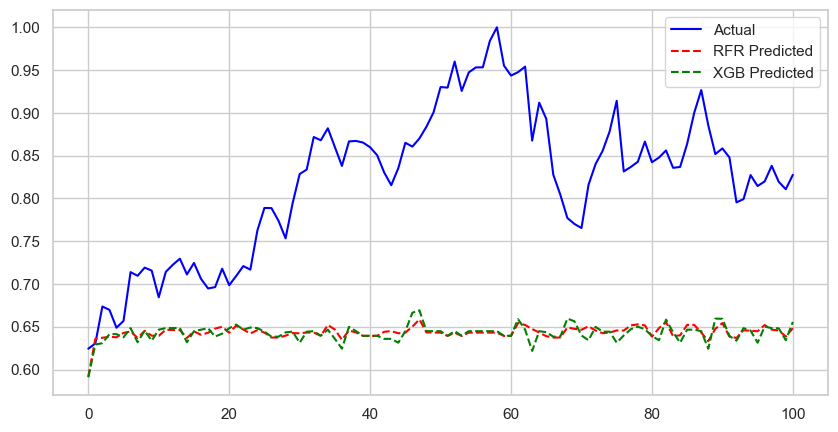

In [51]:
rfr = RandomForestRegressor(n_estimators=100, random_state=42)
xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)

rfr.fit(X_train, y_train)
xgb.fit(X_train, y_train)

y_pred_rfr = rfr.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

metrics = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'MAE': [
        mean_absolute_error(y_test, y_pred_rfr),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    'MSE': [
        mean_squared_error(y_test, y_pred_rfr),
        mean_squared_error(y_test, y_pred_xgb)
    ],
    'R2': [
        r2_score(y_test, y_pred_rfr),
        r2_score(y_test, y_pred_xgb)
    ]
})

print(metrics)

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual', color='blue')
plt.plot(y_pred_rfr, label='RFR Predicted', color='red', linestyle='--')
plt.plot(y_pred_xgb, label='XGB Predicted', color='green', linestyle='--')
plt.legend()
plt.show()